In [1]:
# ¿Un árbol de decisión o un ensamble de árboles predice mejor el consumo de combustible (MPG) que las especificaciones de P200, sobre exactamente la misma partición?

from pathlib import Path

DATA_PATH = Path("../data/auto_mpg.csv")
SUBMISSION_PATH = Path("../submission")

In [2]:
# Estos contratos detienen el flujo antes de entrenar o sobrescribir artefactos con insumos inválidos.

import os

assert DATA_PATH.is_file(), f"No se encontró el archivo de datos: {DATA_PATH}"
assert DATA_PATH.stat().st_size > 0, f"El archivo de datos está vacío: {DATA_PATH}"
assert SUBMISSION_PATH.is_dir(), f"No se encontró el directorio de artefactos: {SUBMISSION_PATH}"
assert os.access(SUBMISSION_PATH, os.W_OK), f"No hay permiso de escritura en: {SUBMISSION_PATH}"

In [3]:
# Se repite la limpieza de P200 sobre el mismo caso: eliminar nulos y tratar Origin como categoría sin orden.

import pandas as pd

dataset = pd.read_csv(DATA_PATH)
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].astype("category")
dataset.shape

(392, 8)

In [4]:
# Se repite la misma partición de P200 para que el MSE sea comparable fila por fila.

from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(
    dataset,
    train_size=0.8,
    random_state=0,
)

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

len(train_features), len(test_features)

(313, 79)

In [5]:
# Se reutiliza el mismo contrato de preprocesamiento de P200 (H06): escalar las entradas numéricas y codificar Origin sin imponer orden.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = train_features.select_dtypes(include="number").columns.tolist()
categorical_features = ["Origin"]

features_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "origin",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
)

In [6]:
# Se recalculan, sobre esta misma partición, los dos extremos ya conocidos de P200: adivinar el promedio y una regresión lineal con todas las entradas.

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

naive_mean_model = DummyRegressor(strategy="mean")
naive_mean_model.fit(train_features, train_labels)

linear_model = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", LinearRegression()),
])
linear_model.fit(train_features, train_labels)

model_comparison_rows = [
    {
        "model": "naive_mean_baseline",
        "test_mse": mean_squared_error(test_labels, naive_mean_model.predict(test_features)),
    },
    {
        "model": "linear_model",
        "test_mse": mean_squared_error(test_labels, linear_model.predict(test_features)),
    },
]
pd.DataFrame(model_comparison_rows)

,model,test_mse
0,naive_mean_baseline,62.188135
1,linear_model,10.022425


In [7]:
# ¿Qué pasa si se deja crecer el árbol sin límite de profundidad? A diferencia de P200, aquí las interacciones no se escriben a mano: el árbol las descubre partiendo el espacio de entradas.

from sklearn.tree import DecisionTreeRegressor

full_tree = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=0)),
])
full_tree.fit(train_features, train_labels)

full_tree_train_mse = mean_squared_error(train_labels, full_tree.predict(train_features))
full_tree_test_mse = mean_squared_error(test_labels, full_tree.predict(test_features))
full_tree_train_mse, full_tree_test_mse

(0.0, 15.879620253164553)

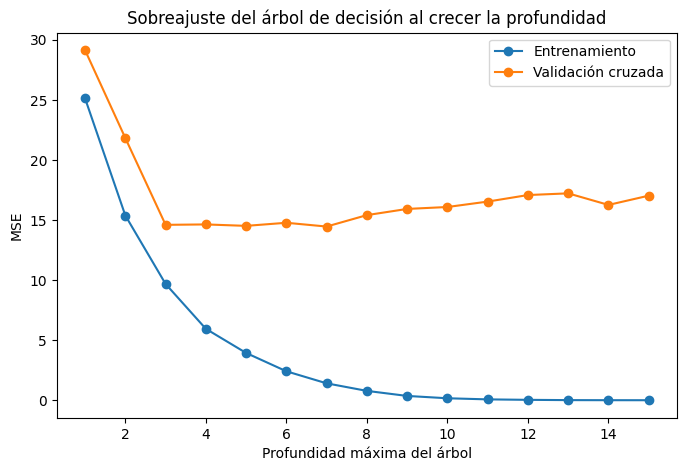

In [8]:
# La curva de validación muestra en qué profundidad el árbol deja de generalizar y empieza a memorizar el entrenamiento.

import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

max_depth_range = list(range(1, 16))
tree_pipeline = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=0)),
])

train_scores, validation_scores = validation_curve(
    tree_pipeline,
    train_features,
    train_labels,
    param_name="regressor__max_depth",
    param_range=max_depth_range,
    scoring="neg_mean_squared_error",
    cv=5,
)

train_mse_by_depth = -train_scores.mean(axis=1)
validation_mse_by_depth = -validation_scores.mean(axis=1)

figure_validation, axis_validation = plt.subplots(figsize=(8, 5))
axis_validation.plot(max_depth_range, train_mse_by_depth, marker="o", label="Entrenamiento")
axis_validation.plot(max_depth_range, validation_mse_by_depth, marker="o", label="Validación cruzada")
axis_validation.set_xlabel("Profundidad máxima del árbol")
axis_validation.set_ylabel("MSE")
axis_validation.set_title("Sobreajuste del árbol de decisión al crecer la profundidad")
axis_validation.legend()
plt.show()

In [9]:
# Se fija la profundidad donde la validación cruzada deja de mejorar, en vez de usar el árbol sin límite.

import numpy as np

best_depth = max_depth_range[int(np.argmin(validation_mse_by_depth))]

decision_tree = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=best_depth, random_state=0)),
])
decision_tree.fit(train_features, train_labels)

model_comparison_rows.append({
    "model": f"decision_tree_depth_{best_depth}",
    "test_mse": mean_squared_error(test_labels, decision_tree.predict(test_features)),
})
best_depth

7

In [10]:
# ¿Promediar muchos árboles (bagging) reduce la varianza de un solo árbol?

from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=0)),
])
random_forest.fit(train_features, train_labels)

model_comparison_rows.append({
    "model": "random_forest",
    "test_mse": mean_squared_error(test_labels, random_forest.predict(test_features)),
})
model_comparison_rows[-1]

{'model': 'random_forest', 'test_mse': 5.710429797468348}

In [11]:
# ¿Ajustar cada árbol sobre el error del anterior (boosting) supera al bagging?

from sklearn.ensemble import HistGradientBoostingRegressor

gradient_boosting = Pipeline([
    ("preprocessor", features_preprocessor),
    ("regressor", HistGradientBoostingRegressor(random_state=0)),
])
gradient_boosting.fit(train_features, train_labels)

model_comparison_rows.append({
    "model": "gradient_boosting",
    "test_mse": mean_squared_error(test_labels, gradient_boosting.predict(test_features)),
})

model_comparison = pd.DataFrame(model_comparison_rows).sort_values("test_mse").reset_index(drop=True)
model_comparison

,model,test_mse
0,gradient_boosting,5.254939
1,random_forest,5.710430
2,linear_model,10.022425
3,decision_tree_depth_7,15.391747
4,naive_mean_baseline,62.188135


In [12]:
# El bosque aleatorio admite dos lecturas de importancia: una interna del ajuste (impureza, sobre las columnas ya codificadas) y otra que mide el efecto de romper cada variable original en la muestra de prueba.

from sklearn.inspection import permutation_importance

feature_names_encoded = random_forest.named_steps["preprocessor"].get_feature_names_out()
impurity_importances = pd.Series(
    random_forest.named_steps["regressor"].feature_importances_,
    index=feature_names_encoded,
).sort_values(ascending=False)

permutation_result = permutation_importance(
    random_forest, test_features, test_labels, n_repeats=30, random_state=0,
)
permutation_importances = pd.Series(
    permutation_result.importances_mean, index=test_features.columns,
).sort_values(ascending=False)

impurity_importances, permutation_importances

(numeric__Weight          0.352174
 numeric__Cylinders       0.207774
 numeric__Displacement    0.147849
 numeric__Horsepower      0.144472
 numeric__Model Year      0.110463
 numeric__Acceleration    0.031847
 origin__Origin_3         0.002093
 origin__Origin_2         0.001715
 origin__Origin_1         0.001614
 dtype: float64,
 Model Year      0.245218
 Weight          0.238602
 Horsepower      0.073565
 Displacement    0.034445
 Cylinders       0.033109
 Acceleration    0.016335
 Origin          0.005204
 dtype: float64)

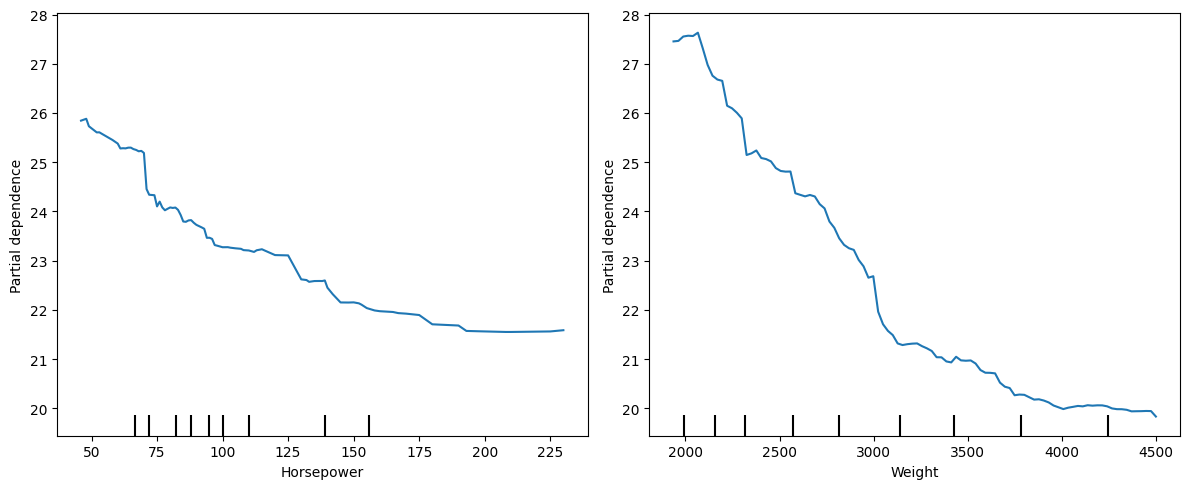

In [13]:
# La dependencia parcial muestra cómo cambia la predicción al mover una variable mientras las demás quedan en sus valores observados; no es un efecto causal.

from sklearn.inspection import PartialDependenceDisplay

figure_pdp, axes_pdp = plt.subplots(1, 2, figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    random_forest, train_features, features=["Horsepower", "Weight"], ax=axes_pdp,
)
plt.tight_layout()
plt.show()

In [14]:
# Se conservan la comparación, las dos lecturas de importancia y las gráficas como evidencia de qué mecanismo aporta y cuál no.

import pickle

model_comparison.to_csv(SUBMISSION_PATH / "model_comparison.csv", index=False)

feature_importances = pd.concat(
    [
        impurity_importances.rename("importance").rename_axis("feature").reset_index().assign(method="impureza"),
        permutation_importances.rename("importance").rename_axis("feature").reset_index().assign(method="permutacion"),
    ],
    ignore_index=True,
)
feature_importances.to_csv(SUBMISSION_PATH / "feature_importances.csv", index=False)

figure_validation.savefig(SUBMISSION_PATH / "validation_curve.png", dpi=150, bbox_inches="tight")
figure_pdp.savefig(SUBMISSION_PATH / "partial_dependence.png", dpi=150, bbox_inches="tight")

for name, model in [
    ("decision_tree", decision_tree),
    ("random_forest", random_forest),
    ("gradient_boosting", gradient_boosting),
]:
    with open(SUBMISSION_PATH / f"{name}.pkl", "wb") as file:
        pickle.dump(model, file)

# gradient_boosting (MSE 5.25) y random_forest (5.71) superan con claridad la regresión lineal
# de P200 (10.02) sobre esta misma partición. Un solo árbol sin restricción memoriza el
# entrenamiento (MSE de entrenamiento = 0.0) pero no mejora en prueba (15.88) frente a limitarlo
# a profundidad 7, la que eligió la validación cruzada (15.39): la ganancia real viene de
# combinar muchos árboles (bagging o boosting), no de dejar crecer uno solo.
#
# Las dos lecturas de importancia del bosque aleatorio difieren: por impureza, Cylinders aparece
# como la segunda variable más importante (0.21), pero por permutación sobre prueba cae a un
# nivel similar a Displacement y Acceleration (0.03), mientras Model Year sube al primer lugar
# (0.25). La impureza se calcula sobre el ajuste de entrenamiento y puede sobreestimar variables
# con muchos puntos de corte posibles; la permutación mide el efecto en datos que el modelo no
# vio. Origin se fragmenta en tres indicadores por impureza (≈0.002 cada uno) pero se lee como
# una sola variable por permutación (0.005); ambas lecturas coinciden en que aporta poco.
#
# Ningún resultado prueba que Weight o Model Year causen el consumo: la dependencia parcial sólo
# describe la asociación que el bosque aprendió sobre este caso y esta partición, no un
# experimento, y no debe leerse como una palanca de rediseño del vehículo.